In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", palette="muted")

df = pd.read_csv("weatherAUS.csv")
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [20]:
# create Rain indicator + select numeric features
df['Rain'] = df['Precip Type'].apply(lambda x: 1 if x=='rain' else 0)

num_cols = [
    'Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
    'Wind Speed (km/h)', 'Wind Bearing (degrees)',
    'Visibility (km)', 'Pressure (millibars)'
]

df_clean = df[num_cols + ['Rain']].copy()
df_clean = df_clean.dropna()
df_clean.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Rain
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,1
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,1
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,1
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,1
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,1


In [21]:
# normalize features
for col in num_cols:
    mn, mx = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = (df_clean[col] - mn) / (mx - mn)

df_clean.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Rain
0,0.506975,0.523486,0.89,0.221130,0.699164,0.983,0.970135,1
1,0.505085,0.521084,0.86,0.223399,0.721448,0.983,0.970613,1
2,0.505445,0.553144,0.89,0.061523,0.568245,0.929,0.970909,1
3,0.487805,0.501947,0.83,0.220877,0.749304,0.983,0.971358,1
4,0.495365,0.517356,0.83,0.172970,0.721448,0.983,0.971454,1


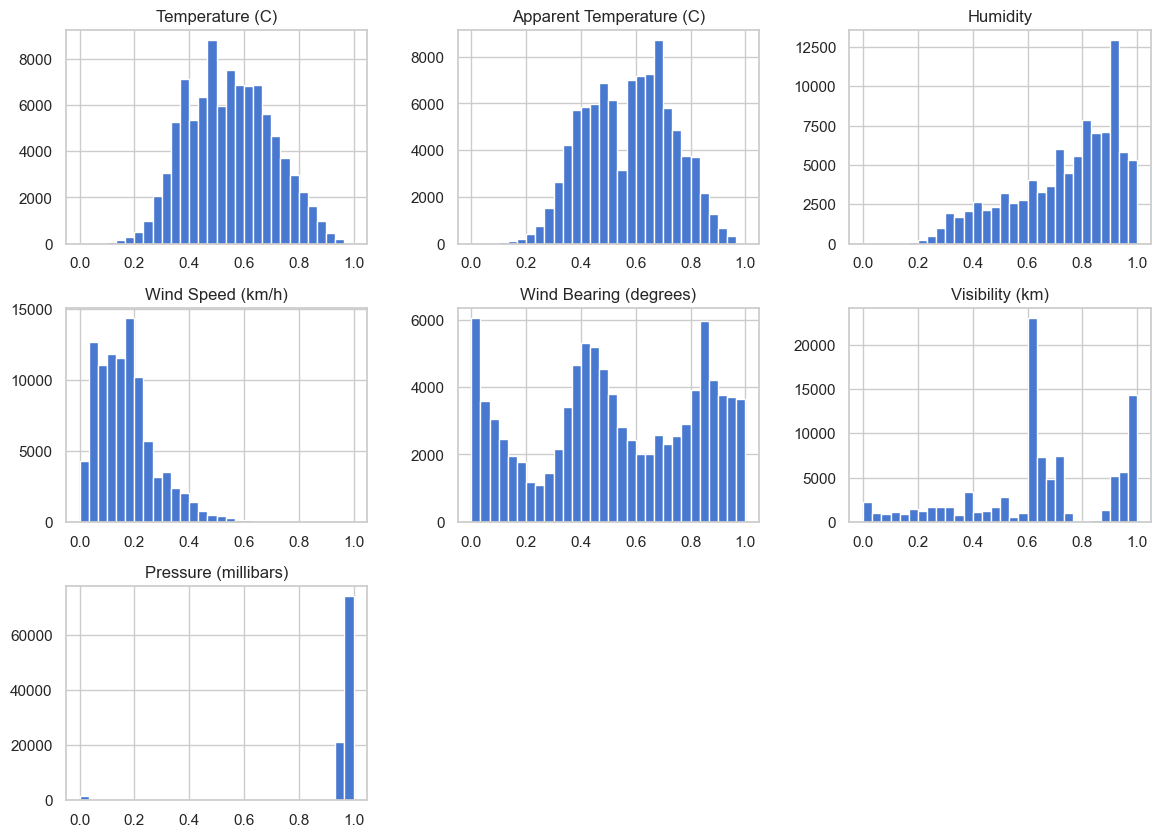

In [22]:
df_clean[num_cols].hist(figsize=(14,10), bins=30)
plt.show()

In [23]:
# logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

X = df_clean[num_cols]
y = df_clean['Rain']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)


In [24]:
acc = accuracy_score(y_test,y_pred)
prec = precision_score(y_test,y_pred)
rec = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
acc, prec, rec, f1

(0.9816494738479083, 0.9855816940050202, 0.9937025484079807, 0.98962546157904)

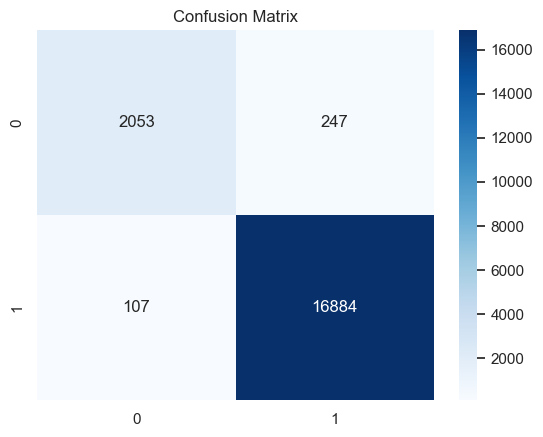

In [25]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

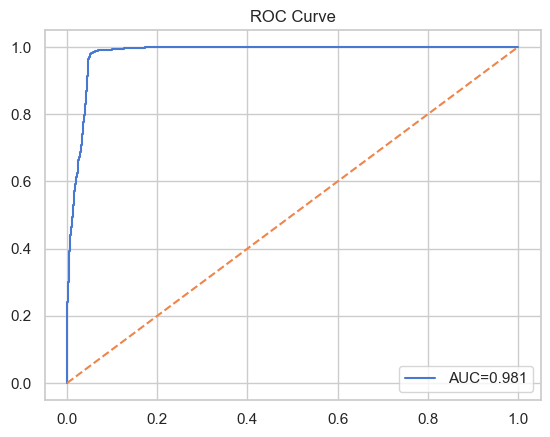

In [26]:
y_prob = log_reg.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()